# Clustering: K-Means -- Mall Customer Segmentation

The Titanic dataset was really built for *classification* (it has a clear label). This notebook uses a dataset actually designed for **unsupervised** clustering: the classic **Mall Customer Segmentation** dataset -- 200 mall members with `Age`, `Annual Income (k$)`, and `Spending Score (1-100)` (a behavioral score assigned by the mall, 1-100, based on purchasing habits). There is no label to predict -- the goal is purely to discover natural customer segments from these features, something a marketing team could act on directly (e.g. "target this group with a loyalty program").

Pipeline:
1. Get the data
2. Profile the data
3. Clean the data
4. Select & scale features for clustering
5. Elbow method: choose `k` using inertia
6. Silhouette score: a second opinion on `k`
7. Fit the final K-Means model
8. Visualize clusters directly (only 3 features -- no PCA needed here, unlike the Titanic notebook)
9. Interpret & name the clusters (business-friendly segment profiles)
10. Inference: assign a new customer to a segment
11. Save the model

## 0. Install & Import Libraries

In [1]:
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries loaded.")


Libraries loaded.


## 1. Get the Data

Loading the dataset from a local cache under `data/` if it exists; otherwise downloading it from the public source below and saving a local copy for next time:

`https://raw.githubusercontent.com/lucko515/clustering-python/master/Customer%20in%20Mall%20clusterng/Mall_Customers.csv`

Each row is one mall member: `CustomerID`, `Genre` (gender), `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/lucko515/clustering-python/master/Customer%20in%20Mall%20clusterng/Mall_Customers.csv"
DATA_DIR = "data"
LOCAL_PATH = os.path.join(DATA_DIR, "Mall_Customers.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(LOCAL_PATH):
    print(f"Loading data from local cache: {LOCAL_PATH}")
    df_raw = pd.read_csv(LOCAL_PATH)
else:
    print(f"Local file not found. Downloading from {DATA_URL} ...")
    df_raw = pd.read_csv(DATA_URL)
    df_raw.to_csv(LOCAL_PATH, index=False)
    print(f"Saved local copy to: {LOCAL_PATH}")

print("Shape:", df_raw.shape)
df_raw.head()


Local file not found. Downloading from https://raw.githubusercontent.com/lucko515/clustering-python/master/Customer%20in%20Mall%20clusterng/Mall_Customers.csv ...
Saved local copy to: data\Mall_Customers.csv
Shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Profile the Data

In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
print("Missing values per column:")
print(df_raw.isna().sum())

print("\nSummary statistics:")
df_raw.describe()


Missing values per column:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Summary statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


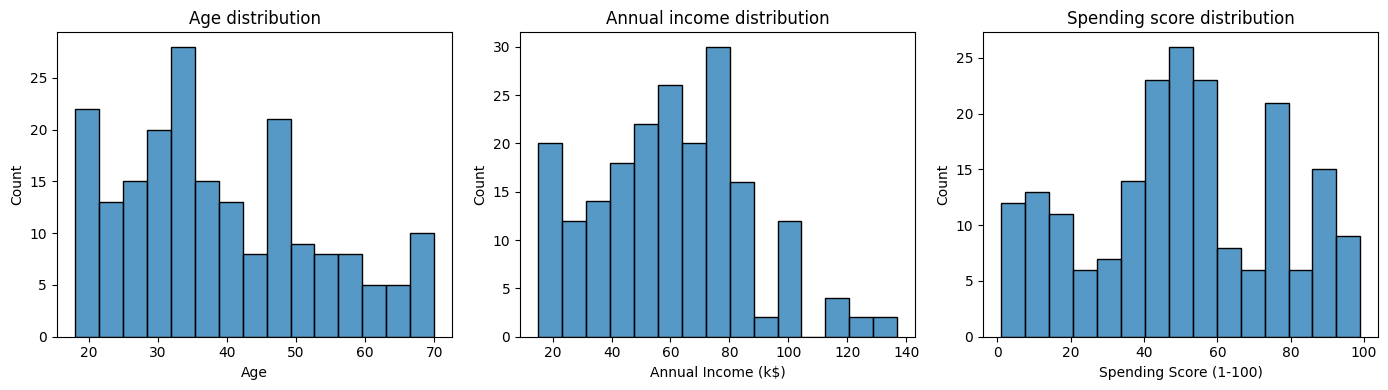

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(df_raw["Age"], bins=15, ax=axes[0])
axes[0].set_title("Age distribution")

sns.histplot(df_raw["Annual Income (k$)"], bins=15, ax=axes[1])
axes[1].set_title("Annual income distribution")

sns.histplot(df_raw["Spending Score (1-100)"], bins=15, ax=axes[2])
axes[2].set_title("Spending score distribution")

plt.tight_layout()
plt.show()


No missing values and a clean, small dataset -- a good fit for the classic customer-segmentation use case this dataset is built for.

## 3. Clean the Data

1. Check for true duplicate rows.
2. Drop `CustomerID` -- a unique identifier, no predictive/clustering value, same reasoning as dropping `PassengerId`/`customerID` in the earlier notebooks.

In [5]:
df = df_raw.copy()

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows -> {len(df)} rows remaining")

df = df.drop(columns=["CustomerID"])
df.head()


Dropped 0 duplicate rows -> 200 rows remaining


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## 4. Select & Scale Features for Clustering

We'll cluster on the three core numeric features: `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`. `Genre` (gender) is set aside for now -- it's kept for later interpretation, similar to how `Survived` was set aside in the Titanic clustering notebook, but not used to form the clusters themselves.

As with the Titanic K-Means notebook, **scaling is essential**: K-Means measures Euclidean distance to centroids, and `Annual Income (k$)` (range ~15-140) would otherwise dominate over `Spending Score` (range 1-100) and `Age` (range ~18-70) purely because of its larger numeric scale, not because it's actually more important.

In [6]:
cluster_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

scaler = StandardScaler()
X_proc = scaler.fit_transform(df[cluster_features])

print("Scaled feature means (should be ~0):", X_proc.mean(axis=0).round(3))
print("Scaled feature stds (should be ~1) :", X_proc.std(axis=0).round(3))


Scaled feature means (should be ~0): [-0. -0. -0.]
Scaled feature stds (should be ~1) : [1. 1. 1.]


## 5. Elbow Method: Choosing `k` with Inertia

Sweep `k` and plot inertia (within-cluster sum of squared distances). Inertia always decreases as `k` grows, so we're looking for the **elbow** -- the point where the drop stops being steep.

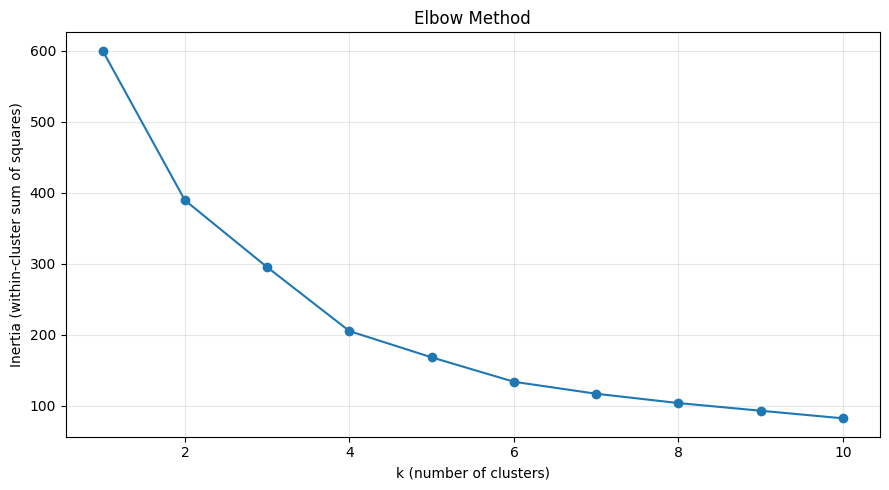

In [7]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    model.fit(X_proc)
    inertias.append(model.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_values), inertias, "-o")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.set_title("Elbow Method")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Silhouette Score: a Second Opinion

A second, more precise signal for `k`: for each point, compare its average distance to points in its own cluster vs. the nearest other cluster (range -1 to +1, higher is better-separated). We pick the `k` that **maximizes** the mean silhouette score.

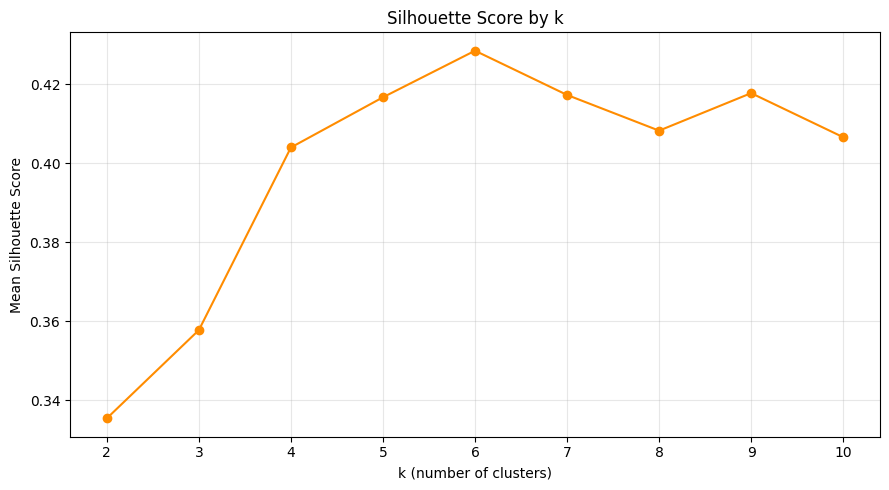

,k,silhouette_score
0,2,0.335472
1,3,0.357793
2,4,0.403958
3,5,0.416643
4,6,0.428417
5,7,0.417232
6,8,0.408207
7,9,0.417693
8,10,0.406554


In [8]:
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = model.fit_predict(X_proc)
    score = silhouette_score(X_proc, labels)
    silhouette_scores.append({"k": k, "silhouette_score": score})

silhouette_df = pd.DataFrame(silhouette_scores)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(silhouette_df["k"], silhouette_df["silhouette_score"], "-o", color="darkorange")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Mean Silhouette Score")
ax.set_title("Silhouette Score by k")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

silhouette_df


In [9]:
BEST_K = int(silhouette_df.loc[silhouette_df["silhouette_score"].idxmax(), "k"])
print(f"Selected k = {BEST_K} (highest mean silhouette score)")


Selected k = 6 (highest mean silhouette score)


## 7. Fit the Final K-Means Model

In [10]:
final_kmeans = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_proc)

df["cluster"] = cluster_labels
print(pd.Series(cluster_labels).value_counts().sort_index().rename("customer_count"))


0    45
1    39
2    33
3    39
4    23
5    21
Name: customer_count, dtype: int64


## 8. Visualize the Clusters

Unlike the Titanic notebook (10 processed dimensions, needing PCA to visualize), this dataset only has 3 clustering features -- we can plot `Annual Income` vs. `Spending Score` directly, which is exactly the classic view for this dataset and tends to show very clean, visually separable segments.

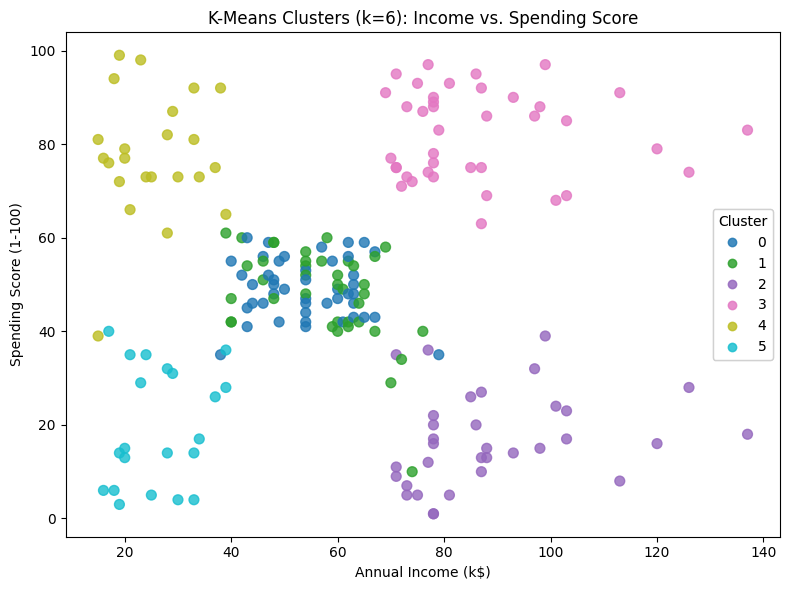

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    df["Annual Income (k$)"], df["Spending Score (1-100)"],
    c=cluster_labels, cmap="tab10", s=50, alpha=0.8,
)
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1-100)")
ax.set_title(f"K-Means Clusters (k={BEST_K}): Income vs. Spending Score")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.show()


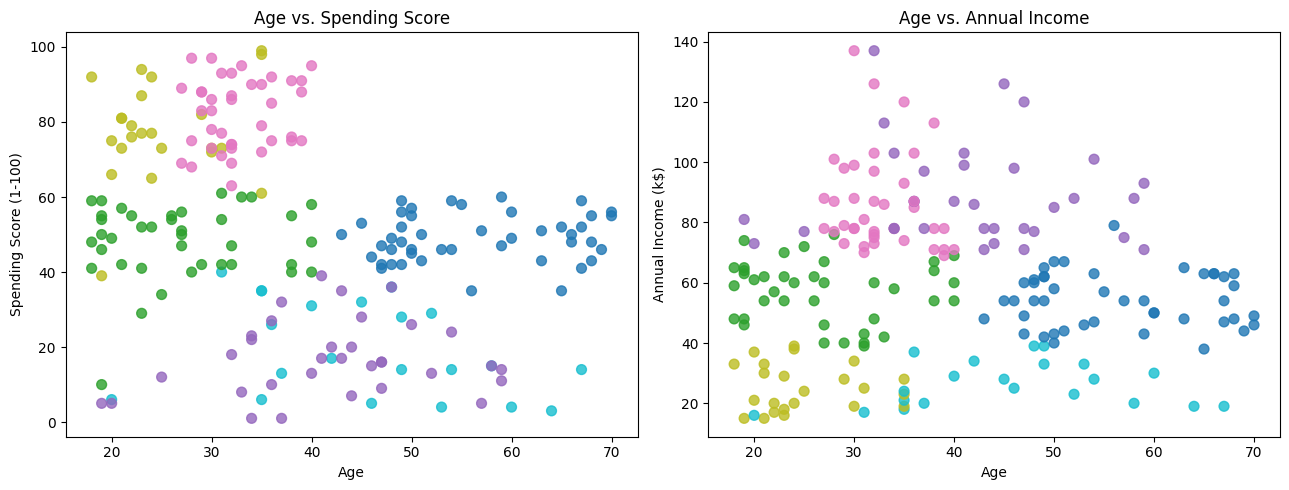

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["Age"], df["Spending Score (1-100)"], c=cluster_labels, cmap="tab10", s=50, alpha=0.8)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Spending Score (1-100)")
axes[0].set_title("Age vs. Spending Score")

axes[1].scatter(df["Age"], df["Annual Income (k$)"], c=cluster_labels, cmap="tab10", s=50, alpha=0.8)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Annual Income (k$)")
axes[1].set_title("Age vs. Annual Income")

plt.tight_layout()
plt.show()


## 9. Interpret & Name the Clusters

Group the original (unscaled) feature values by cluster to build a plain-English profile of each segment -- exactly the kind of output a marketing team would use to decide who to target with what.

In [13]:
cluster_profile = df.groupby("cluster")[cluster_features].mean().round(1)
cluster_profile["customer_count"] = df["cluster"].value_counts().sort_index()
cluster_profile["most_common_genre"] = df.groupby("cluster")["Genre"].agg(lambda s: s.mode()[0])

cluster_profile


,Age,Annual Income (k$),Spending Score (1-100),customer_count,most_common_genre
cluster,,,,,
0,56.3,54.3,49.1,45,Female
1,26.8,57.1,48.1,39,Female
2,41.9,88.9,17.0,33,Male
3,32.7,86.5,82.1,39,Female
4,25.0,25.3,77.6,23,Female
5,45.5,26.3,19.4,21,Female


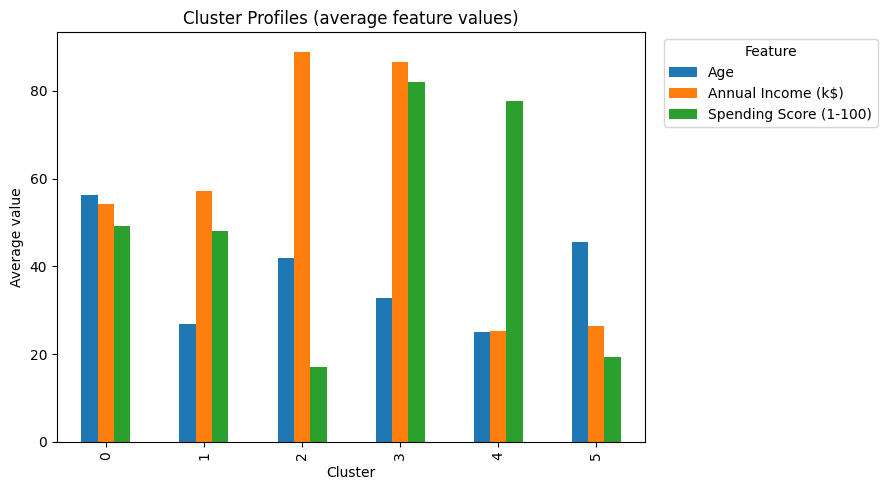

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
cluster_profile[cluster_features].plot(kind="bar", ax=ax)
ax.set_xlabel("Cluster")
ax.set_ylabel("Average value")
ax.set_title("Cluster Profiles (average feature values)")
ax.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Typical segment story for this dataset (exact cluster numbers may vary by run, but the shapes tend to be consistent):
- **High income, high spending** -- prime targets for premium offers and loyalty programs.
- **High income, low spending** -- financially able but not currently engaged; worth investigating why (wrong product mix? competing malls?).
- **Low income, high spending** -- price-sensitive but enthusiastic shoppers; good candidates for discounts and value promotions.
- **Low income, low spending** -- lowest priority for marketing spend.
- **Average income, average spending** -- the "middle," typically the largest, least distinctive segment.

## 10. Inference: Assign a New Customer to a Segment

In [15]:
def assign_cluster(age, annual_income_k, spending_score, model, scaler):
    input_df = pd.DataFrame([{
        "Age": age,
        "Annual Income (k$)": annual_income_k,
        "Spending Score (1-100)": spending_score,
    }])
    input_scaled = scaler.transform(input_df)
    cluster = model.predict(input_scaled)[0]
    distances = model.transform(input_scaled)[0]
    return cluster, distances


cluster, distances = assign_cluster(age=27, annual_income_k=85, spending_score=90, model=final_kmeans, scaler=scaler)
print(f"Assigned cluster: {cluster}")
print("Distance to each cluster centroid:", np.round(distances, 3))
print("\nThat segment's profile:")
print(cluster_profile.loc[cluster])


Assigned cluster: 3
Distance to each cluster centroid: [2.887 1.943 3.035 0.514 2.335 3.782]

That segment's profile:
Age                         32.7
Annual Income (k$)          86.5
Spending Score (1-100)      82.1
customer_count                39
most_common_genre         Female
Name: 3, dtype: object


## 11. Save the Model (optional)

In [16]:
joblib.dump({"model": final_kmeans, "scaler": scaler, "features": cluster_features}, "mall_kmeans.joblib")
print("Model + scaler saved to mall_kmeans.joblib")

# To reload later:
# bundle = joblib.load("mall_kmeans.joblib")
# final_kmeans, scaler, cluster_features = bundle["model"], bundle["scaler"], bundle["features"]


Model + scaler saved to mall_kmeans.joblib
